In [1]:
import matplotlib.pyplot as plt
import datetime as dt
import pandas as pd
import numpy as np
import scipy as sp

from pathlib import Path
import soundfile as sf
import json
import subprocess

In [2]:
import folium

In [3]:
import UBNA_localize_process_GCC__20250505 as localize

In [4]:
SD_CARD_TO_AUDIOMOTH_NUM = {'STF_026': '014', 'STF_028' : '045', 
                            'STF_057': '015', 'STF_109': '008', 
                            'STF_114': '040', 'STF_053': '032', 
                            'STF_021': '016', 'STF_116': '036', 
                            'STF_060': '004', 'STF_025': '042',  
                            'STF_027': '020',
                            'STF_113': '044', 'STF_030': '012'}
FREQ_UPPER_LIM = 6/8
SD_CARD_TO_AUDIOMOTH_NUM

{'STF_026': '014',
 'STF_028': '045',
 'STF_057': '015',
 'STF_109': '008',
 'STF_114': '040',
 'STF_053': '032',
 'STF_021': '016',
 'STF_116': '036',
 'STF_060': '004',
 'STF_025': '042',
 'STF_027': '020',
 'STF_113': '044',
 'STF_030': '012'}

In [5]:
AUDIOMOTH_AT_PATCHA = {'014':'A1 (top)', '045':'A1 (bottom)',
                       '015':'A4 (top)', '008':'A4 (bottom)',
                       '040':'A7 (top)', '032':'A7 (bottom)'}
AUDIOMOTH_AT_PATCHE = {'016':'E2 (top)', '036':'E2 (bottom)',
                       '004':'E4 (top)', '042':'E4 (bottom)',
                       '020':'E8 (alone)',
                       '044':'E9 (top)', '012':'E9 (bottom)'}

AUDIOMOTH_AT_ALLPATCHES = AUDIOMOTH_AT_PATCHA | AUDIOMOTH_AT_PATCHE

In [6]:
photo_dir = Path.home() / "Downloads/audiomoth50_fencepost_pics"
photo_paths = sorted(photo_dir.rglob("*.HEIC"))

photo_metadata = []
if len(photo_paths) > 0:
    photo_metadata = json.loads(subprocess.check_output(["exiftool", "-json", "-n", *[str(path) for path in photo_paths]], text=True))

photo_marker_locations = []
for photo_metadata_row in photo_metadata:
    if "GPSLatitude" in photo_metadata_row and "GPSLongitude" in photo_metadata_row:
        photo_name = Path(photo_metadata_row["SourceFile"]).parent.name
        photo_location = [photo_metadata_row["GPSLatitude"], photo_metadata_row["GPSLongitude"]]
        photo_marker_locations.append((photo_name, photo_location, "lime"))

measurement_csv_path = photo_dir / "post_A7/Raw Data.csv"
measurement_marker_locations = []
if measurement_csv_path.exists():
    measurement_points = pd.read_csv(measurement_csv_path)
    measurement_points = measurement_points[int(len(measurement_points) * (0.4)):int(len(measurement_points) * (0.6))]
    measurement_points = measurement_points[["Latitude (°)", "Longitude (°)"]].dropna().copy()
    for measurement_row_i, measurement_row in measurement_points.iterrows():
        measurement_name = measurement_csv_path.parent.name
        measurement_location = [measurement_row["Latitude (°)"], measurement_row["Longitude (°)"]]
        measurement_marker_locations.append((measurement_name, measurement_location, "magenta"))

marker_locations = photo_marker_locations + measurement_marker_locations

   13 image files read


In [7]:
from pyproj import Transformer

post_order = ["post_A7", "post_A1", "post_A4", "post_E2", "post_E4", "post_E8", "post_E9"]

post_points = pd.DataFrame([{"post": name, "lat": location[0], "lon": location[1]}
                            for name, location, fill_color in marker_locations
                            if name in post_order])

missing_posts = [post_name for post_name in post_order if post_name not in set(post_points["post"])]
if len(missing_posts) > 0:
    raise ValueError(f"Missing post points for: {missing_posts}")

average_post_locations = post_points.groupby("post")[["lat", "lon"]].mean().loc[post_order]
average_post_locations

,lat,lon
post,,
post_A7,47.655097,-122.296698
post_A1,47.655707,-122.296649
post_A4,47.655381,-122.296653
post_E2,47.654839,-122.295539
post_E4,47.654944,-122.294883
post_E8,47.654442,-122.294875
post_E9,47.654286,-122.295294


In [8]:
A_locs_mat_tdoa = np.array([np.concatenate([average_post_locations.loc['post_A1'].values, [6.5]]), #A1 BOTTOM
                            np.concatenate([average_post_locations.loc['post_A4'].values, [6.5]]), #A4 BOTTOM
                            np.concatenate([average_post_locations.loc['post_A4'].values, [7.5]]), #A4 TOP
                            np.concatenate([average_post_locations.loc['post_A7'].values, [6.5]]), #A7 BOTTOM
                            np.concatenate([average_post_locations.loc['post_A1'].values, [7.5]])]) #A1 TOP
ref_A_loc = np.concatenate([average_post_locations.loc['post_A7'].values, [7.5]])
A_locs_mat_tdoa, ref_A_loc

(array([[  47.65570741, -122.29664907,    6.5       ],
        [  47.65538056, -122.29665278,    6.5       ],
        [  47.65538056, -122.29665278,    7.5       ],
        [  47.65509726, -122.29669809,    6.5       ],
        [  47.65570741, -122.29664907,    7.5       ]]),
 array([  47.65509726, -122.29669809,    7.5       ]))

In [9]:
A1_ground_truth_latlon = [47 + (39.3437 / 60), -(122 + (17.8028 / 60))]
A4_ground_truth_latlon = [47 + (39.3243 / 60), -(122 + (17.8002 / 60))]
A7_ground_truth_latlon = [47 + (39.3061 / 60), -(122 + (17.8012 / 60))]

GROUND_TRUTH_LOCS = {'STF_026': A1_ground_truth_latlon, 'STF_028' : A1_ground_truth_latlon,
                     'STF_057': A4_ground_truth_latlon, 'STF_109': A4_ground_truth_latlon,
                     'STF_114': A7_ground_truth_latlon, 'STF_053': A7_ground_truth_latlon}
GROUND_TRUTH_LOCS

{'STF_026': [47.655728333333336, -122.29671333333333],
 'STF_028': [47.655728333333336, -122.29671333333333],
 'STF_057': [47.655405, -122.29667],
 'STF_109': [47.655405, -122.29667],
 'STF_114': [47.65510166666667, -122.29668666666667],
 'STF_053': [47.65510166666667, -122.29668666666667]}

In [10]:
A_locs_mat_tdoa = np.array([np.concatenate([np.array(A1_ground_truth_latlon), [6.5]]), #A1 BOTTOM
                            np.concatenate([np.array(A4_ground_truth_latlon), [6.5]]), #A4 BOTTOM
                            np.concatenate([np.array(A4_ground_truth_latlon), [7.5]]), #A4 TOP
                            np.concatenate([np.array(A7_ground_truth_latlon), [6.5]]), #A7 BOTTOM
                            np.concatenate([np.array(A1_ground_truth_latlon), [7.5]])]) #A1 TOP
ref_A_loc = np.concatenate([np.array(A7_ground_truth_latlon), [7.5]])
A_locs_mat_tdoa, ref_A_loc

(array([[  47.65572833, -122.29671333,    6.5       ],
        [  47.655405  , -122.29667   ,    6.5       ],
        [  47.655405  , -122.29667   ,    7.5       ],
        [  47.65510167, -122.29668667,    6.5       ],
        [  47.65572833, -122.29671333,    7.5       ]]),
 array([  47.65510167, -122.29668667,    7.5       ]))

In [11]:
# WGS84 longitude/latitude/elevation -> ECEF XYZ meters.
# always_xy=True means transform(lon, lat, height), even though EPSG:4979's
# formal axis order is lat, lon, height.
lla_to_ecef = Transformer.from_crs("EPSG:4979", "EPSG:4978", always_xy=True)

In [12]:
def latlon_delta_xy_m(lat1, lon1, lat2, lon2):
    R = 6371000
    lat0 = (lat1 + lat2) / 2
    dx = R * np.radians(lon2 - lon1) * np.cos(np.radians(lat0))
    dy = R * np.radians(lat2 - lat1)
    return dx, dy

In [13]:
A_locs_mat_tdoa_meters = np.zeros(A_locs_mat_tdoa.shape)
for channel_num in range(5):
    coords = A_locs_mat_tdoa[channel_num]
    x, y = latlon_delta_xy_m(ref_A_loc[0], ref_A_loc[1], coords[0], coords[1])
    A_locs_mat_tdoa_meters[channel_num] = np.array([x, y, -(coords[2] - ref_A_loc[2])])

In [14]:
A_locs_mat_tdoa_meters

array([[-1.9973214 , 69.68215403,  1.        ],
       [ 1.24832974, 33.72912775,  1.        ],
       [ 1.24832974, 33.72912775, -0.        ],
       [ 0.        ,  0.        ,  1.        ],
       [-1.9973214 , 69.68215403, -0.        ]])

In [15]:
ref_A_loc_meters = np.array([0, 0, 0])
ref_A_loc_meters

array([0, 0, 0])

In [16]:
x0 = ref_A_loc_meters[0]
y0 = ref_A_loc_meters[1]
z0 = ref_A_loc_meters[2]

In [17]:
NUM_NONREFCHANNELS = 5

In [18]:
xm = A_locs_mat_tdoa_meters[:,0].reshape((NUM_NONREFCHANNELS, 1))
ym = A_locs_mat_tdoa_meters[:,1].reshape((NUM_NONREFCHANNELS, 1))
zm = A_locs_mat_tdoa_meters[:,2].reshape((NUM_NONREFCHANNELS, 1))

In [19]:
UBNA_ARRAY_MIC_LOCS = np.vstack([A_locs_mat_tdoa_meters, ref_A_loc_meters])
UBNA_ARRAY_MIC_LOCS

array([[-1.9973214 , 69.68215403,  1.        ],
       [ 1.24832974, 33.72912775,  1.        ],
       [ 1.24832974, 33.72912775, -0.        ],
       [ 0.        ,  0.        ,  1.        ],
       [-1.9973214 , 69.68215403, -0.        ],
       [ 0.        ,  0.        ,  0.        ]])

In [20]:
measured_d_mics_to_ref = np.array([69.95949479, 33.61578646, 33.26028125,  2.19913021, 69.11271354])

In [21]:
measured_dm0_column = measured_d_mics_to_ref.reshape((NUM_NONREFCHANNELS, 1))
measured_dm0_column

array([[69.95949479],
       [33.61578646],
       [33.26028125],
       [ 2.19913021],
       [69.11271354]])

In [22]:
true_distances = np.sqrt(np.sum(A_locs_mat_tdoa_meters**2, axis=1))
true_distances

array([69.7179452 , 33.76703105, 33.75222046,  1.        , 69.71077308])

In [23]:
measured_dm0_column = true_distances.reshape(-1, 1)

In [24]:
A_mat = np.hstack(((A_locs_mat_tdoa_meters), measured_dm0_column))
A_mat

array([[-1.9973214 , 69.68215403,  1.        , 69.7179452 ],
       [ 1.24832974, 33.72912775,  1.        , 33.76703105],
       [ 1.24832974, 33.72912775, -0.        , 33.75222046],
       [ 0.        ,  0.        ,  1.        ,  1.        ],
       [-1.9973214 , 69.68215403, -0.        , 69.71077308]])

In [25]:
wm0 = ((xm**2 + ym**2 + zm**2) - (x0**2 + y0**2+ z0**2) - (measured_dm0_column**2))/2
wm0

array([[4.54747351e-13],
       [0.00000000e+00],
       [1.13686838e-13],
       [0.00000000e+00],
       [4.54747351e-13]])

In [26]:
xs, residuals, rank, sing_vals = sp.linalg.lstsq(A_mat, wm0)
xs[:,0]

array([-6.74251434e-14, -5.20517159e-14, -5.72498989e-14,  5.70295467e-14])

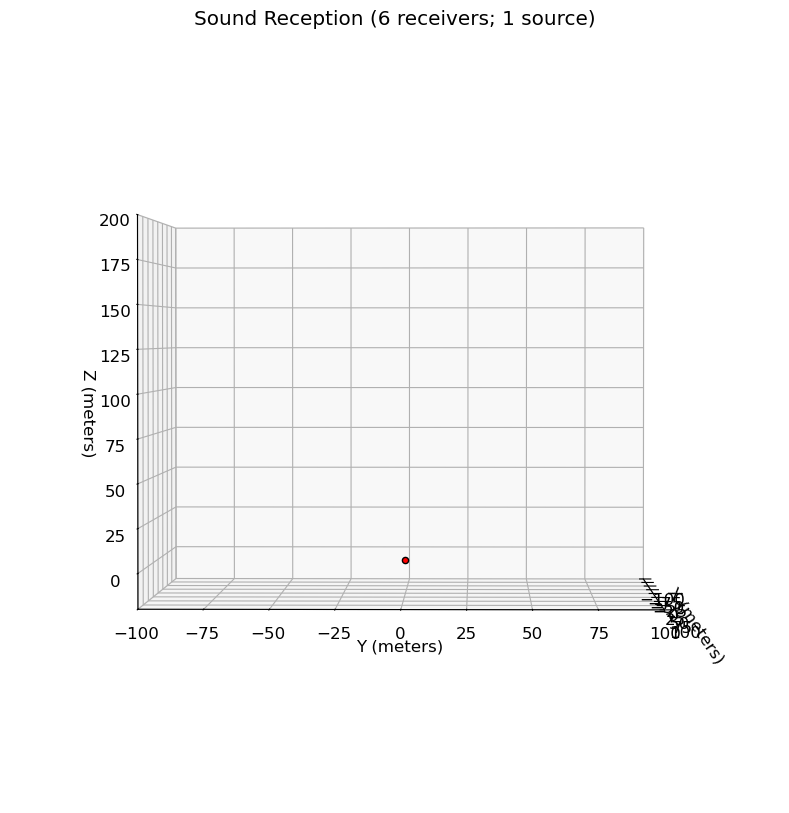

In [27]:
fig = plt.figure(figsize=(15, 10))
plt.rcParams.update({'font.size':12})
map_ax_3d = fig.add_subplot(projection='3d')
POINT_SIZE = 40
GRID_SIZE = 200
rN_x = UBNA_ARRAY_MIC_LOCS[:,0]
rN_y = UBNA_ARRAY_MIC_LOCS[:,1]
rN_z = UBNA_ARRAY_MIC_LOCS[:,2]

# map_ax_3d.scatter(rN_x, rN_y, rN_z, s=10, color='yellow', edgecolor='k', zorder=1)
map_ax_3d.scatter(xs[0,0], xs[1,0], xs[2,0], color='r', edgecolor='k', alpha=1, s=POINT_SIZE/2, zorder=2)
    
map_ax_3d.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
map_ax_3d.set_ylim(-GRID_SIZE / 2, GRID_SIZE / 2)
map_ax_3d.set_zlim(-GRID_SIZE / 10, GRID_SIZE)
map_ax_3d.set_xlabel("X (meters)")
map_ax_3d.set_ylabel("Y (meters)")
map_ax_3d.set_zlabel("Z (meters)")
map_ax_3d.set_title(f"Sound Reception ({int(NUM_NONREFCHANNELS+1)} receivers; 1 source)")
map_ax_3d.view_init(elev=1, azim=1)

plt.show()

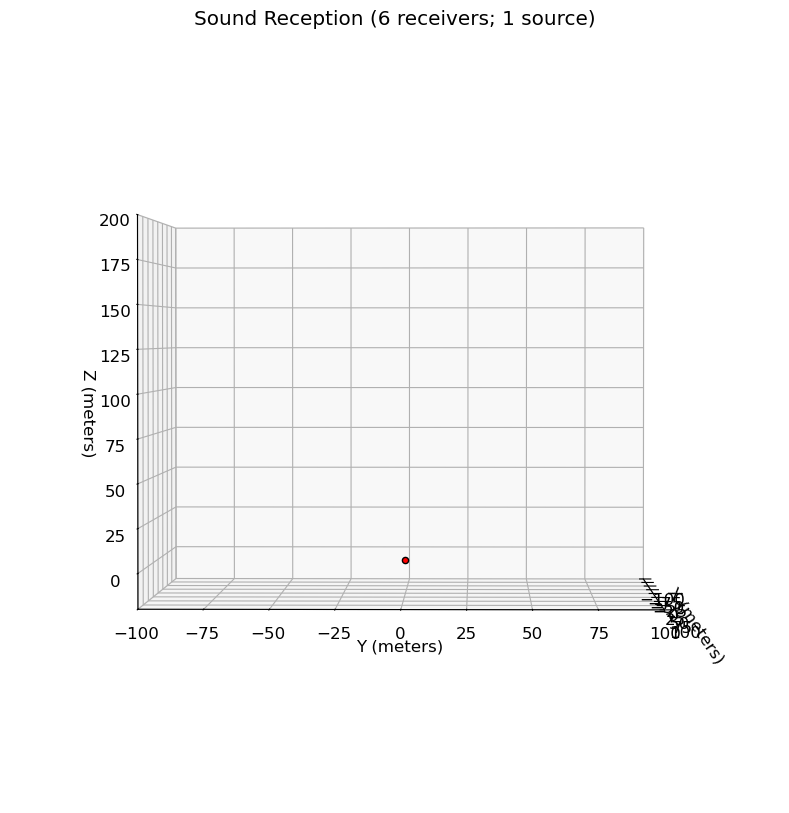

In [28]:
# measured_d_mics_to_ref = np.array([69.95949479, 33.61578646, 33.26028125,  2.19913021, 69.11271354])
measured_d_mics_to_ref = np.sqrt(np.sum(A_locs_mat_tdoa_meters**2, axis=1))


measured_dm0_column = measured_d_mics_to_ref.reshape((NUM_NONREFCHANNELS, 1))

A_mat = np.hstack(((A_locs_mat_tdoa_meters), measured_dm0_column))
wm0 = ((xm**2 + ym**2 + zm**2) - (x0**2 + y0**2+ z0**2) - (measured_dm0_column**2))/2
xs, residuals, rank, sing_vals = sp.linalg.lstsq(A_mat, wm0)

fig = plt.figure(figsize=(15, 10))
plt.rcParams.update({'font.size':12})
map_ax_3d = fig.add_subplot(projection='3d')
POINT_SIZE = 40
GRID_SIZE = 200
rN_x = UBNA_ARRAY_MIC_LOCS[:,0]
rN_y = UBNA_ARRAY_MIC_LOCS[:,1]
rN_z = UBNA_ARRAY_MIC_LOCS[:,2]

# map_ax_3d.scatter(rN_x, rN_y, rN_z, s=10, color='yellow', edgecolor='k', zorder=1)
map_ax_3d.scatter(xs[0,0], xs[1,0], xs[2,0], color='r', edgecolor='k', alpha=1, s=POINT_SIZE/2, zorder=2)
    
map_ax_3d.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
map_ax_3d.set_ylim(-GRID_SIZE / 2, GRID_SIZE / 2)
map_ax_3d.set_zlim(-GRID_SIZE / 10, GRID_SIZE)
map_ax_3d.set_xlabel("X (meters)")
map_ax_3d.set_ylabel("Y (meters)")
map_ax_3d.set_zlabel("Z (meters)")
map_ax_3d.set_title(f"Sound Reception ({int(NUM_NONREFCHANNELS+1)} receivers; 1 source)")
map_ax_3d.view_init(elev=1, azim=1)

plt.show()

In [29]:
import ipywidgets as widgets
from IPython.display import display, clear_output

%matplotlib widget

initial_measured_d_mics_to_ref = np.array([69.95949479, 33.61578646, 33.26028125,  2.19913021, 69.11271354])
# initial_measured_d_mics_to_ref = np.sqrt(np.sum(A_locs_mat_tdoa_meters**2, axis=1))
slider_labels = ["A1 bottom", "A4 bottom", "A4 top", "A7 bottom", "A1 top"]
slider_range_m = 1

distance_sliders = []
for label, distance in zip(slider_labels, initial_measured_d_mics_to_ref):
    slider = widgets.FloatSlider(
        value=float(distance),
        min=max(0, float(distance) - slider_range_m),
        max=float(distance) + slider_range_m,
        step=0.01,
        description=label,
        continuous_update=False,
        readout_format=".2f",
        style={"description_width": "90px"},
        layout=widgets.Layout(width="450px"),
    )
    distance_sliders.append(slider)
plot_output = widgets.Output()

def solve_tdoa_from_distances(measured_d_mics_to_ref):
    measured_dm0_column = measured_d_mics_to_ref.reshape((NUM_NONREFCHANNELS, 1))
    A_mat = np.hstack((A_locs_mat_tdoa_meters, measured_dm0_column))
    wm0 = ((xm**2 + ym**2 + zm**2) - (x0**2 + y0**2 + z0**2) - (measured_dm0_column**2)) / 2
    return sp.linalg.lstsq(A_mat, wm0)

def update_localization_plot(change=None):
    measured_d_mics_to_ref = np.array([slider.value for slider in distance_sliders])
    xs, residuals, rank, sing_vals = solve_tdoa_from_distances(measured_d_mics_to_ref)
    with plot_output:
        clear_output(wait=True)
        print(f"xs = [{xs[0,0]:.3f}, {xs[1,0]:.3f}, {xs[2,0]:.3f}, {xs[3,0]:.3f}]")
        print(f"residuals = {residuals}; rank = {rank}")
        fig = plt.figure(figsize=(15, 10))
        plt.rcParams.update({'font.size': 12})
        map_ax_3d = fig.add_subplot(projection='3d')
        POINT_SIZE = 40
        GRID_SIZE = 200
        rN_x = UBNA_ARRAY_MIC_LOCS[:,0]
        rN_y = UBNA_ARRAY_MIC_LOCS[:,1]
        rN_z = UBNA_ARRAY_MIC_LOCS[:,2]
        map_ax_3d.scatter(rN_x, rN_y, rN_z, s=POINT_SIZE, color='yellow', edgecolor='k', zorder=1)
        map_ax_3d.scatter(xs[0,0], xs[1,0], xs[2,0], color='r', edgecolor='k', alpha=1, s=POINT_SIZE, zorder=2)
        map_ax_3d.scatter(0, 0, 0, color='cyan', edgecolor='k', alpha=1, s=POINT_SIZE, zorder=3)
        map_ax_3d.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
        map_ax_3d.set_ylim(-GRID_SIZE / 2, GRID_SIZE / 2)
        map_ax_3d.set_zlim(-GRID_SIZE / 10, GRID_SIZE)
        map_ax_3d.set_xlabel("X (meters)")
        map_ax_3d.set_ylabel("Y (meters)")
        map_ax_3d.set_zlabel("Z (meters)")
        map_ax_3d.set_title(f"Sound Reception ({int(NUM_NONREFCHANNELS + 1)} receivers; 1 source)")
        map_ax_3d.view_init(elev=1, azim=1)
        plt.show()

for slider in distance_sliders:
    slider.observe(update_localization_plot, names="value")

update_localization_plot()
display(widgets.VBox(distance_sliders), plot_output)



Output()

In [30]:
import ipywidgets as widgets
from IPython.display import display, clear_output

%matplotlib widget

# initial_measured_d_mics_to_ref = np.array([69.95949479, 33.61578646, 33.26028125,  2.19913021, 69.11271354])
initial_measured_d_mics_to_ref = np.sqrt(np.sum(A_locs_mat_tdoa_meters**2, axis=1))
slider_labels = ["A1 bottom", "A4 bottom", "A4 top", "A7 bottom", "A1 top"]
slider_range_m = 1

distance_sliders = []
for label, distance in zip(slider_labels, initial_measured_d_mics_to_ref):
    slider = widgets.FloatSlider(
        value=float(distance),
        min=max(0, float(distance) - slider_range_m),
        max=float(distance) + slider_range_m,
        step=0.01,
        description=label,
        continuous_update=False,
        readout_format=".2f",
        style={"description_width": "90px"},
        layout=widgets.Layout(width="450px"),
    )
    distance_sliders.append(slider)
plot_output = widgets.Output()

def solve_tdoa_from_distances(measured_d_mics_to_ref):
    measured_dm0_column = measured_d_mics_to_ref.reshape((NUM_NONREFCHANNELS, 1))
    A_mat = np.hstack((A_locs_mat_tdoa_meters, measured_dm0_column))
    wm0 = ((xm**2 + ym**2 + zm**2) - (x0**2 + y0**2 + z0**2) - (measured_dm0_column**2)) / 2
    return sp.linalg.lstsq(A_mat, wm0)

def update_localization_plot(change=None):
    measured_d_mics_to_ref = np.array([slider.value for slider in distance_sliders])
    xs, residuals, rank, sing_vals = solve_tdoa_from_distances(measured_d_mics_to_ref)
    with plot_output:
        clear_output(wait=True)
        print(f"xs = [{xs[0,0]:.3f}, {xs[1,0]:.3f}, {xs[2,0]:.3f}, {xs[3,0]:.3f}]")
        print(f"residuals = {residuals}; rank = {rank}")
        fig = plt.figure(figsize=(15, 10))
        plt.rcParams.update({'font.size': 12})
        map_ax_3d = fig.add_subplot(projection='3d')
        POINT_SIZE = 40
        GRID_SIZE = 200
        rN_x = UBNA_ARRAY_MIC_LOCS[:,0]
        rN_y = UBNA_ARRAY_MIC_LOCS[:,1]
        rN_z = UBNA_ARRAY_MIC_LOCS[:,2]
        map_ax_3d.scatter(rN_x, rN_y, rN_z, s=POINT_SIZE, color='yellow', edgecolor='k', zorder=1)
        map_ax_3d.scatter(xs[0,0], xs[1,0], xs[2,0], color='r', edgecolor='k', alpha=1, s=POINT_SIZE, zorder=2)
        map_ax_3d.scatter(0, 0, 0, color='cyan', edgecolor='k', alpha=1, s=POINT_SIZE, zorder=3)
        map_ax_3d.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
        map_ax_3d.set_ylim(-GRID_SIZE / 2, GRID_SIZE / 2)
        map_ax_3d.set_zlim(-GRID_SIZE / 10, GRID_SIZE)
        map_ax_3d.set_xlabel("X (meters)")
        map_ax_3d.set_ylabel("Y (meters)")
        map_ax_3d.set_zlabel("Z (meters)")
        map_ax_3d.set_title(f"Sound Reception ({int(NUM_NONREFCHANNELS + 1)} receivers; 1 source)")
        map_ax_3d.view_init(elev=1, azim=1)
        plt.show()

for slider in distance_sliders:
    slider.observe(update_localization_plot, names="value")

update_localization_plot()
display(widgets.VBox(distance_sliders), plot_output)



Output()